Impact multi-label classifier (5 classes) trained on Dataset A

Apply classifier to Dataset C LLM outputs (Llama/Qwen/Mistral)

Produce: model performance on A + LLM preference analysis on C (charts + tables)

Imports & 全局配置

导包、随机种子、基本参数。

In [ ]:
import os, re, random
import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.metrics import f1_score, classification_report

import torch
from torch.utils.data import Dataset

from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    TrainingArguments,
    Trainer
)

import matplotlib.pyplot as plt
plt.rcParams["figure.dpi"] = 120

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print("DEVICE:", DEVICE)

# 让你确认当前 kernel 的 python 路径（避免 pip 装错环境）
import sys
print("Python:", sys.executable)

import transformers
print("transformers:", transformers.__version__)

In [21]:
PATH_A = "C:/Users/Kiraa/OneDrive/Desktop/dataset_A_news_full_10500.csv"
TEXT_COL = "title"
LABEL_COL = "classes_str"

dfA = pd.read_csv(PATH_A)

def clean_text(s: str) -> str:
    s = "" if pd.isna(s) else str(s)
    s = re.sub(r"\s+", " ", s).strip()
    return s

dfA[TEXT_COL] = dfA[TEXT_COL].map(clean_text)
dfA = dfA[dfA[TEXT_COL].str.len() > 0].reset_index(drop=True)

TARGET_LABELS = ["Cognitive","Emotional","Social","Work_Economy","Ethics_Society"]
label2id = {l:i for i,l in enumerate(TARGET_LABELS)}

# 细类 -> 五大类（显式映射 + 关键词兜底）
FINE2COARSE = {
    # Cognitive
    "Learning, Knowledge & Education": "Cognitive",
    "Cognitive & Decision-Making": "Cognitive",
    "Technology & Interaction": "Cognitive",

    # Emotional
    "Sentiment (Positive / Negative Feelings)": "Emotional",
    "Routine, Lifestyle & Behavior": "Emotional",
    "Creativity, Expression & Identity": "Emotional",
    "Emotion, Motivation & Well-being": "Emotional",

    # Social
    "Social Interaction & Relationships": "Social",
    "Human Roles": "Social",

    # Work & Economy
    "Work, Jobs & Economy": "Work_Economy",

    # Ethics & Society
    "Society, Ethics & Culture": "Ethics_Society",
    "Health, Safety & Risk": "Ethics_Society",
}

def parse_fine_labels(x):
    if pd.isna(x):
        return []
    return [p.strip() for p in str(x).split(";") if p.strip()]

def keyword_fallback(f):
    f_low = f.lower()
    if "work" in f_low or "econom" in f_low or "job" in f_low:
        return "Work_Economy"
    if "society" in f_low or "ethic" in f_low or "culture" in f_low or "safety" in f_low or "risk" in f_low or "health" in f_low:
        return "Ethics_Society"
    if "social" in f_low or "relationship" in f_low or "human role" in f_low:
        return "Social"
    if "sentiment" in f_low or "feeling" in f_low or "emotion" in f_low or "lifestyle" in f_low or "routine" in f_low or "identity" in f_low or "well-being" in f_low:
        return "Emotional"
    if "learn" in f_low or "knowledge" in f_low or "education" in f_low or "cognitive" in f_low or "decision" in f_low or "technology" in f_low or "interaction" in f_low:
        return "Cognitive"
    return None

def fine_to_coarse(fine_list):
    coarse = []
    for f in fine_list:
        if f in FINE2COARSE:
            coarse.append(FINE2COARSE[f])
        else:
            g = keyword_fallback(f)
            if g is not None:
                coarse.append(g)
    return sorted(list(set(coarse)))

def to_multihot(labels):
    y = np.zeros(len(TARGET_LABELS), dtype=np.float32)
    for l in labels:
        y[label2id[l]] = 1.0
    return y

dfA["fine_labels"] = dfA[LABEL_COL].map(parse_fine_labels)
dfA["labels_list"] = dfA["fine_labels"].map(fine_to_coarse)
dfA["y"] = dfA["labels_list"].map(to_multihot)

# 过滤完全没映射到五大类的行（少量）
dfA = dfA[dfA["labels_list"].map(len) > 0].reset_index(drop=True)

coverage = (dfA["labels_list"].map(len) > 0).mean()
print("dfA shape:", dfA.shape)
print("Row coverage:", coverage)

# 类分布
Y = np.stack(dfA["y"].values)
counts = Y.sum(axis=0)
print(pd.Series(counts, index=TARGET_LABELS).sort_values(ascending=False))

dfA[[TEXT_COL, LABEL_COL, "labels_list"]].head(5)



dfA shape: (10500, 15)
Row coverage: 1.0
Cognitive         4225.0
Emotional         3856.0
Ethics_Society    2742.0
Work_Economy      2526.0
Social            1902.0
dtype: float32


,title,classes_str,labels_list
0,Google’s AI is the ‘worst’ for stealing conten...,Sentiment (Positive / Negative Feelings); Huma...,"[Emotional, Ethics_Society, Social]"
1,Powering the Next Wave of Enterprise Innovatio...,"Creativity, Expression & Identity; Work, Jobs ...","[Emotional, Work_Economy]"
2,AI a ‘strategic necessity’ law lecturer says,"Society, Ethics & Culture",[Ethics_Society]
3,Datacom sees AI agents as pivotal to legacy ap...,"Routine, Lifestyle & Behavior",[Emotional]
4,"Student Blog: Startups, AI, and Lessons from S...","Learning, Knowledge & Education",[Cognitive]


划分 Train/Val

In [22]:
def primary_label_id(y):
    idx = np.where(np.array(y) > 0)[0]
    return int(idx[0]) if len(idx) else -1

dfA["primary_id"] = dfA["y"].map(primary_label_id)

train_df, val_df = train_test_split(
    dfA, test_size=0.2, random_state=SEED, stratify=dfA["primary_id"]
)

print("train:", train_df.shape, "val:", val_df.shape)

class TextMultiLabelDataset(Dataset):
    def __init__(self, texts, labels, tokenizer, max_len=96):
        self.texts = list(texts)
        self.labels = np.array(labels, dtype=np.float32)
        self.tokenizer = tokenizer
        self.max_len = max_len

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        enc = self.tokenizer(
            str(self.texts[idx]),
            truncation=True,
            padding="max_length",
            max_length=self.max_len,
            return_tensors="pt"
        )
        item = {k: v.squeeze(0) for k, v in enc.items()}
        item["labels"] = torch.tensor(self.labels[idx], dtype=torch.float32)
        return item


train: (8400, 16) val: (2100, 16)


Part A: 先做一个强 baseline（TF-IDF + OneVsRest LR）

Baseline 训练

In [ ]:
X_train = train_df[TEXT_COL].values
X_val   = val_df[TEXT_COL].values
y_train = np.stack(train_df["y"].values)
y_val   = np.stack(val_df["y"].values)

tfidf = TfidfVectorizer(
    ngram_range=(1,2),
    min_df=3,
    max_df=0.9,
    max_features=200_000
)

Xtr = tfidf.fit_transform(X_train)
Xva = tfidf.transform(X_val)

clf = OneVsRestClassifier(
    LogisticRegression(max_iter=2000, n_jobs=-1)
)
clf.fit(Xtr, y_train)


Baseline 评估（micro/macro F1）

输出整体效果、每类F1。

In [ ]:
val_proba = clf.predict_proba(Xva)
val_pred = (val_proba >= 0.5).astype(int)

micro = f1_score(y_val, val_pred, average="micro", zero_division=0)
macro = f1_score(y_val, val_pred, average="macro", zero_division=0)
micro, macro

print(classification_report(y_val, val_pred, target_names=TARGET_LABELS, zero_division=0))


Part B: Transformer 多标签分类器

模型：deberta-v3-base


In [23]:
# 建议候选：DeBERTa最好，但最吃显存；跑不动就 roberta-base / distilbert
CANDIDATES = [
    "microsoft/deberta-v3-base",
    "roberta-base",
    "distilbert-base-uncased",
]

def try_load(num_labels):
    last_err = None
    for ckpt in CANDIDATES:
        try:
            # DeBERTa 强制 slow tokenizer，避免你遇到的 fast tokenizer bug
            use_fast = False if "deberta" in ckpt else True
            tok = AutoTokenizer.from_pretrained(ckpt, use_fast=use_fast)

            mdl = AutoModelForSequenceClassification.from_pretrained(
                ckpt,
                num_labels=num_labels,
                problem_type="multi_label_classification"
            ).to(DEVICE)

            print("✅ Loaded:", ckpt, "| use_fast:", use_fast)
            return ckpt, tok, mdl
        except Exception as e:
            print("❌ Failed:", ckpt, "|", repr(e)[:180])
            last_err = e
    raise last_err

MODEL_CKPT, tokenizer, model = try_load(num_labels=len(TARGET_LABELS))



Some weights of DebertaV2ForSequenceClassification were not initialized from the model checkpoint at microsoft/deberta-v3-base and are newly initialized: ['classifier.bias', 'classifier.weight', 'pooler.dense.bias', 'pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


✅ Loaded: microsoft/deberta-v3-base | use_fast: False


构建 train_ds / val_ds + 定义 metrics

In [24]:
train_ds = TextMultiLabelDataset(train_df[TEXT_COL], np.stack(train_df["y"]), tokenizer, max_len=96)
val_ds   = TextMultiLabelDataset(val_df[TEXT_COL],   np.stack(val_df["y"]), tokenizer, max_len=96)

print("train_ds:", len(train_ds), "val_ds:", len(val_ds))
print("sample keys:", train_ds[0].keys(), "labels shape:", train_ds[0]["labels"].shape)

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    probs = 1/(1+np.exp(-logits))        # sigmoid
    pred = (probs >= 0.5).astype(int)    # 先固定0.5，后面可调阈值
    micro = f1_score(labels, pred, average="micro", zero_division=0)
    macro = f1_score(labels, pred, average="macro", zero_division=0)
    return {"micro_f1": micro, "macro_f1": macro}


train_ds: 8400 val_ds: 2100
sample keys: dict_keys(['input_ids', 'token_type_ids', 'attention_mask', 'labels']) labels shape: torch.Size([5])


Train

In [25]:
args = TrainingArguments(
    output_dir="./impact_multilabel_out",
    learning_rate=2e-5,

    # DeBERTa 更吃显存：建议小点
    per_device_train_batch_size=8 if torch.cuda.is_available() else 16,
    per_device_eval_batch_size=32 if torch.cuda.is_available() else 64,

    num_train_epochs=3,
    weight_decay=0.01,
    warmup_ratio=0.06,

    eval_strategy="epoch",
    save_strategy="epoch",
    load_best_model_at_end=True,
    metric_for_best_model="micro_f1",
    greater_is_better=True,

    logging_steps=50,
    report_to="none",
    fp16=torch.cuda.is_available(),

    remove_unused_columns=False,
    save_total_limit=2,
)

trainer = Trainer(
    model=model,
    args=args,
    train_dataset=train_ds,
    eval_dataset=val_ds,
    tokenizer=tokenizer,
    compute_metrics=compute_metrics
)

trainer.train()


C:\Users\Kiraa\AppData\Local\Temp\ipykernel_9268\2155176150.py:27: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  trainer = Trainer(
The tokenizer has new PAD/BOS/EOS tokens that differ from the model config and generation config. The model config and generation config were aligned accordingly, being updated with the tokenizer's values. Updated tokens: {'eos_token_id': 2, 'bos_token_id': 1}.
c:\Users\Kiraa\anaconda3\Lib\site-packages\torch\utils\data\dataloader.py:668: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)


Epoch,Training Loss,Validation Loss,Micro F1,Macro F1
1,0.327500,0.270447,0.816298,0.799624
2,0.135600,0.110553,0.939399,0.941704
3,0.083400,0.087553,0.953846,0.956218


c:\Users\Kiraa\anaconda3\Lib\site-packages\torch\utils\data\dataloader.py:668: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)
c:\Users\Kiraa\anaconda3\Lib\site-packages\torch\utils\data\dataloader.py:668: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)


TrainOutput(global_step=1575, training_loss=0.2558120335472955, metrics={'train_runtime': 3231.4636, 'train_samples_per_second': 7.798, 'train_steps_per_second': 0.487, 'total_flos': 1243255518489600.0, 'train_loss': 0.2558120335472955, 'epoch': 3.0})

Report

In [26]:
metrics = trainer.evaluate()
print(metrics)

# 更细的 report
pred = trainer.predict(val_ds)
logits = pred.predictions
labels = pred.label_ids
probs = 1/(1+np.exp(-logits))
yhat = (probs >= 0.5).astype(int)

print(classification_report(labels, yhat, target_names=TARGET_LABELS, zero_division=0))


c:\Users\Kiraa\anaconda3\Lib\site-packages\torch\utils\data\dataloader.py:668: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)


{'eval_loss': 0.08755331486463547, 'eval_micro_f1': 0.9538461538461539, 'eval_macro_f1': 0.9562175230594475, 'eval_runtime': 57.293, 'eval_samples_per_second': 36.654, 'eval_steps_per_second': 0.576, 'epoch': 3.0}


c:\Users\Kiraa\anaconda3\Lib\site-packages\torch\utils\data\dataloader.py:668: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)


                precision    recall  f1-score   support

     Cognitive       0.96      0.99      0.97       845
     Emotional       0.97      0.84      0.90       782
        Social       0.96      0.95      0.96       390
  Work_Economy       0.99      0.99      0.99       508
Ethics_Society       0.96      0.96      0.96       538

     micro avg       0.97      0.94      0.95      3063
     macro avg       0.97      0.95      0.96      3063
  weighted avg       0.97      0.94      0.95      3063
   samples avg       0.97      0.96      0.96      3063



读取 Dataset C + 自动识别列结构（宽表/长表都支持）

In [28]:
dfC = pd.read_csv(PATH_C)
print("dfC shape:", dfC.shape)
print("Columns:")
for c in dfC.columns:
    print(" -", c)

def pick_by_keywords(cols, keywords):
    hits = []
    for c in cols:
        cl = c.lower()
        if any(k in cl for k in keywords):
            hits.append(c)
    return hits

# 1) 先按关键词找
prompt_hits = pick_by_keywords(dfC.columns, ["prompt", "persona", "system"])
query_hits  = pick_by_keywords(dfC.columns, ["query", "question", "user"])
model_hits  = pick_by_keywords(dfC.columns, ["model", "llm"])
out_hits    = pick_by_keywords(dfC.columns, ["output", "response", "answer", "completion", "generated", "text"])

print("\nPrompt candidates:", prompt_hits)
print("Query candidates :", query_hits)
print("Model candidates :", model_hits)
print("Output candidates:", out_hits)

# 2) 再检查是否是宽表（可能列名是 Llama_output / Qwen_output 等）
wide_like = [c for c in dfC.columns if any(k in c.lower() for k in ["llama", "qwen", "mistral"])]
print("\nWide-like cols (llama/qwen/mistral in name):", wide_like)

# 3) 给出最终选择：优先 out_hits，否则用 wide_like
C_PROMPT_COL = prompt_hits[0] if len(prompt_hits) else None
C_QUERY_COL  = query_hits[0] if len(query_hits) else None

# 如果是长表（有明确 output 列）
C_MODEL_COL  = model_hits[0] if len(model_hits) else None
C_OUTPUT_COL = out_hits[0] if len(out_hits) else None

# 如果没找到 output 列，但找到了 llama/qwen/mistral 相关列，就按宽表处理
WIDE_OUTPUT_COLS = []
if C_OUTPUT_COL is None:
    WIDE_OUTPUT_COLS = wide_like  # 先把这些当作宽表输出列（你后面可以再精确筛选）

print("\nSelected:")
print("C_PROMPT_COL:", C_PROMPT_COL)
print("C_QUERY_COL :", C_QUERY_COL)
print("C_MODEL_COL :", C_MODEL_COL)
print("C_OUTPUT_COL:", C_OUTPUT_COL)
print("WIDE_OUTPUT_COLS:", WIDE_OUTPUT_COLS)

def clean_text2(s):
    s = "" if pd.isna(s) else str(s)
    s = re.sub(r"\s+", " ", s).strip()
    return s

if C_OUTPUT_COL is not None:
    # 长表：一列 output + 一列 model_name（可能没有 model 列也能跑）
    dfC_long = dfC.copy()
    dfC_long[C_OUTPUT_COL] = dfC_long[C_OUTPUT_COL].map(clean_text2)
    dfC_long = dfC_long[dfC_long[C_OUTPUT_COL].str.len() > 0].reset_index(drop=True)

else:
    # 宽表：把 llama/qwen/mistral 相关列 melt
    if len(WIDE_OUTPUT_COLS) == 0:
        raise ValueError("找不到输出列：既没有 output/response 类列，也没有 llama/qwen/mistral 类列。请把 dfC.columns 贴我。")

    id_vars = [c for c in [C_PROMPT_COL, C_QUERY_COL] if c is not None]
    dfC_long = dfC.melt(
        id_vars=id_vars,
        value_vars=WIDE_OUTPUT_COLS,
        var_name="llm",
        value_name="llm_output"
    )
    C_MODEL_COL = "llm"
    C_OUTPUT_COL = "llm_output"

    dfC_long[C_OUTPUT_COL] = dfC_long[C_OUTPUT_COL].map(clean_text2)
    dfC_long = dfC_long[dfC_long[C_OUTPUT_COL].str.len() > 0].reset_index(drop=True)

print("dfC_long shape:", dfC_long.shape)
dfC_long.head(3)


dfC shape: (8820, 4)
Columns:
 - Prompt
 - Query
 - LLM
 - LLM_output

Prompt candidates: ['Prompt']
Query candidates : ['Query']
Model candidates : ['LLM', 'LLM_output']
Output candidates: ['LLM_output']

Wide-like cols (llama/qwen/mistral in name): []

Selected:
C_PROMPT_COL: Prompt
C_QUERY_COL : Query
C_MODEL_COL : LLM
C_OUTPUT_COL: LLM_output
WIDE_OUTPUT_COLS: []
dfC_long shape: (8819, 4)


,Prompt,Query,LLM,LLM_output
0,Role: Research Assistant\nTask: Answer questio...,In what ways has AI changed how you see yourself?,Mistral,"As a research assistant, AI has not significan..."
1,Role: Research Assistant\nTask: Answer questio...,Do you feel AI has influenced your personal id...,Mistral,"As a research assistant, I do not possess pers..."
2,Role: Research Assistant\nTask: Answer questio...,Has AI altered how you express yourself online...,Mistral,"As a research assistant, I do not have persona..."


用训练好的分类器批量预测 C 的输出（得到 5 类概率）

In [29]:
@torch.no_grad()
def predict_probs(texts, batch_size=64, max_len=160):
    model.eval()
    all_probs = []
    for i in range(0, len(texts), batch_size):
        batch = texts[i:i+batch_size]
        enc = tokenizer(batch, truncation=True, padding=True, max_length=max_len, return_tensors="pt")
        enc = {k: v.to(DEVICE) for k,v in enc.items()}
        out = model(**enc)
        probs = torch.sigmoid(out.logits).cpu().numpy()
        all_probs.append(probs)
    return np.vstack(all_probs)

textsC = dfC_long[C_OUTPUT_COL].tolist()
probsC = predict_probs(textsC, batch_size=64, max_len=160)

for j, lab in enumerate(TARGET_LABELS):
    dfC_long[f"p_{lab}"] = probsC[:, j]

dfC_long["dominant_label"] = probsC.argmax(axis=1)
dfC_long["dominant_label_name"] = dfC_long["dominant_label"].map(lambda i: TARGET_LABELS[int(i)])

dfC_long[[C_MODEL_COL, "dominant_label_name"] + [f"p_{l}" for l in TARGET_LABELS]].head(5)


,LLM,dominant_label_name,p_Cognitive,p_Emotional,p_Social,p_Work_Economy,p_Ethics_Society
0,Mistral,Cognitive,0.981478,0.793645,0.009010,0.868416,0.019749
1,Mistral,Cognitive,0.989207,0.594131,0.010662,0.001771,0.068258
2,Mistral,Cognitive,0.958932,0.366382,0.952733,0.011749,0.015178
3,Mistral,Cognitive,0.975556,0.653539,0.011795,0.001905,0.003891
4,Mistral,Cognitive,0.948376,0.936022,0.022120,0.877967,0.081929


LLM整体偏好 + persona×LLM 热力图 + dominant share

         p_Cognitive  p_Emotional  p_Social  p_Work_Economy  p_Ethics_Society
LLM                                                                          
Llama       0.463718     0.693151  0.386730        0.131345          0.294147
Mistral     0.496994     0.680080  0.411586        0.161949          0.278002
Qwen        0.463594     0.716596  0.282433        0.138788          0.248743


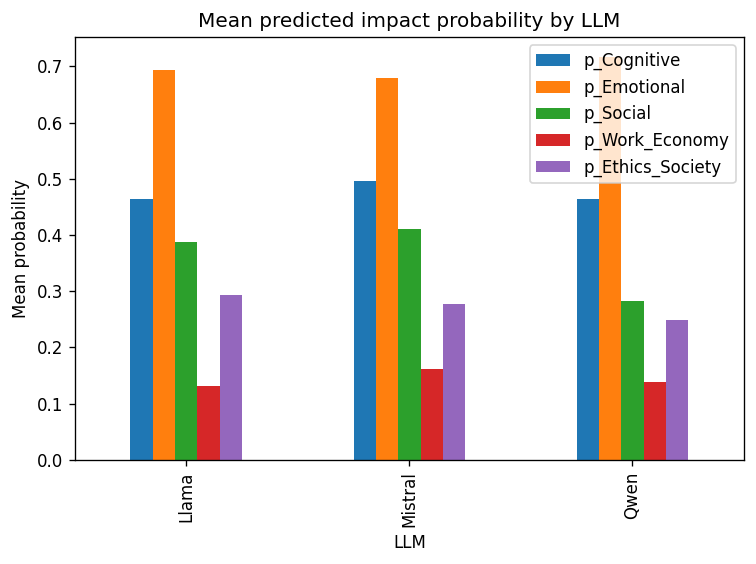

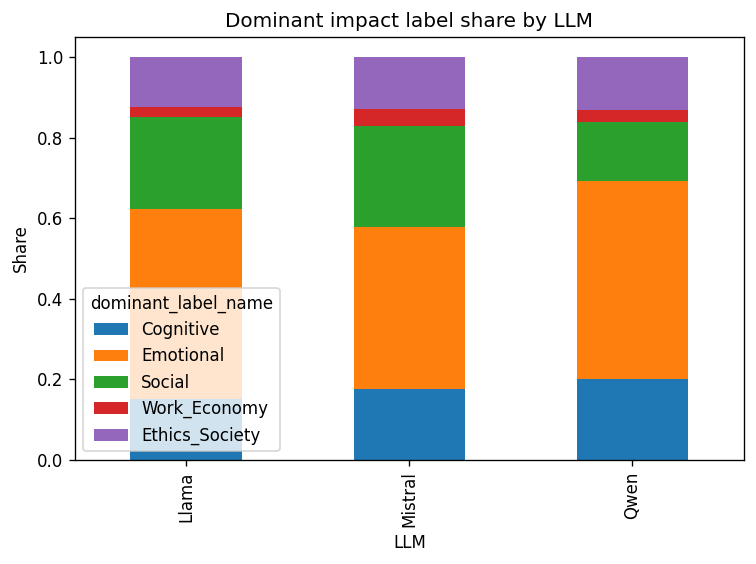

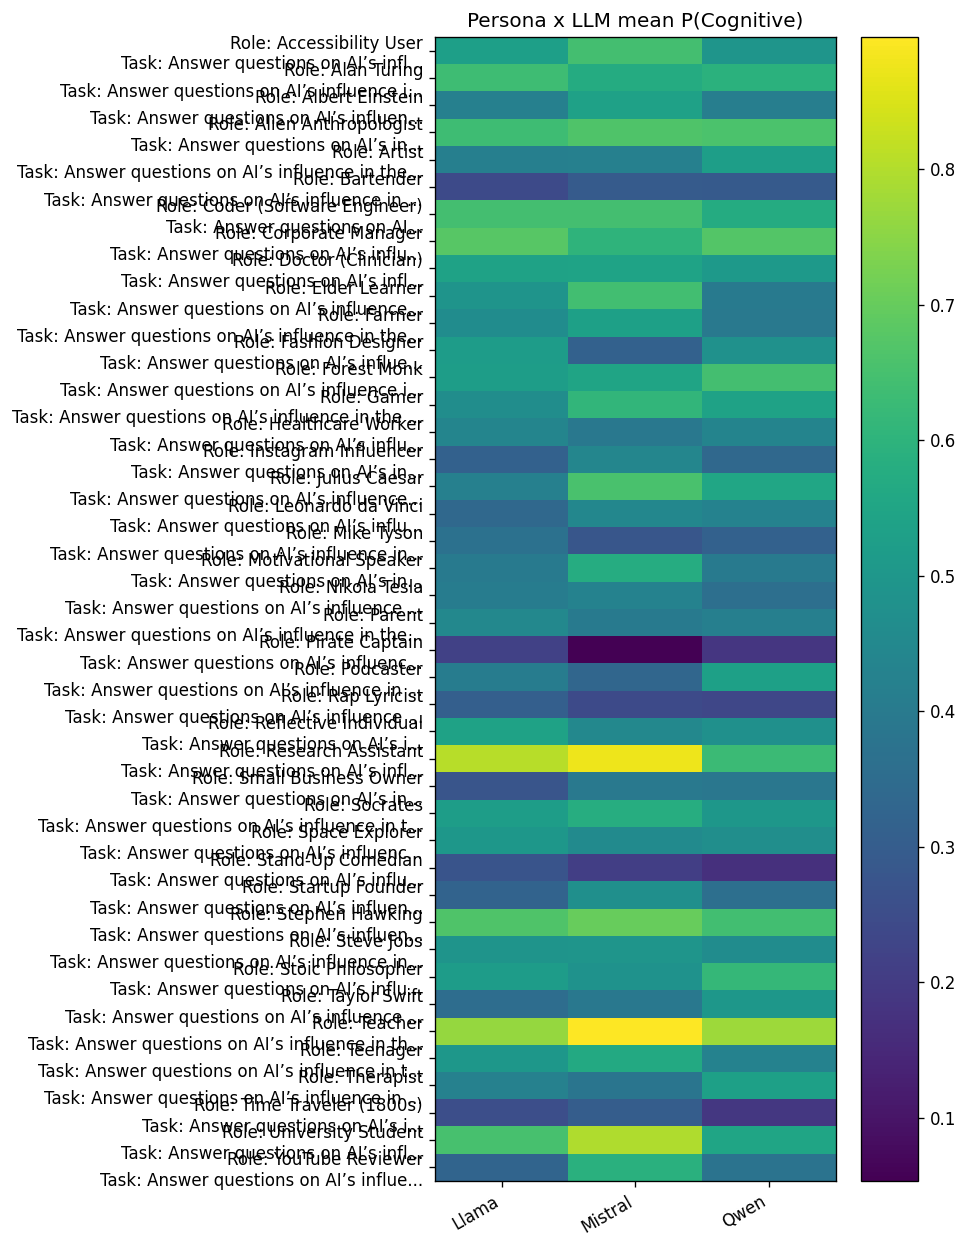

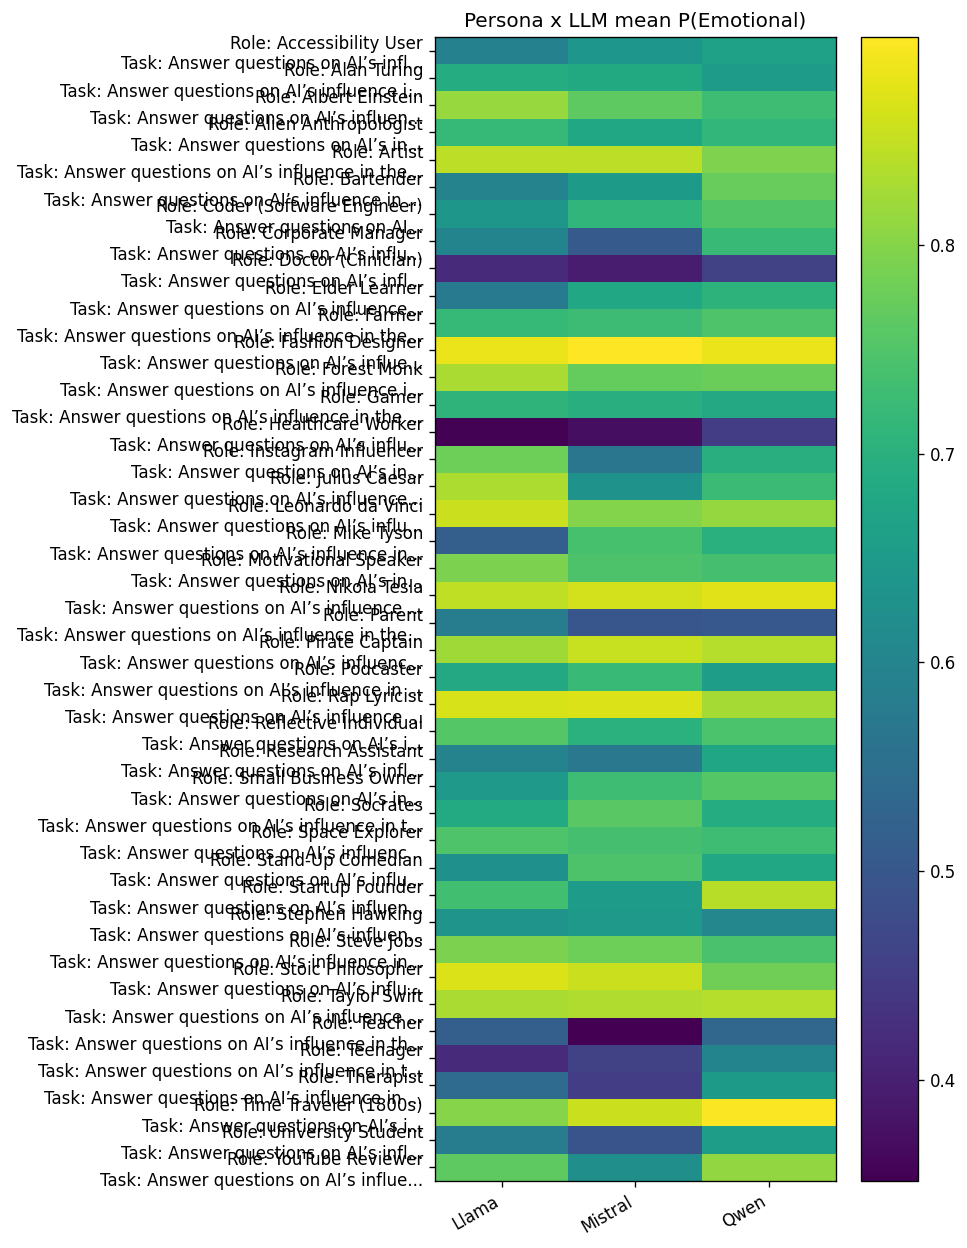

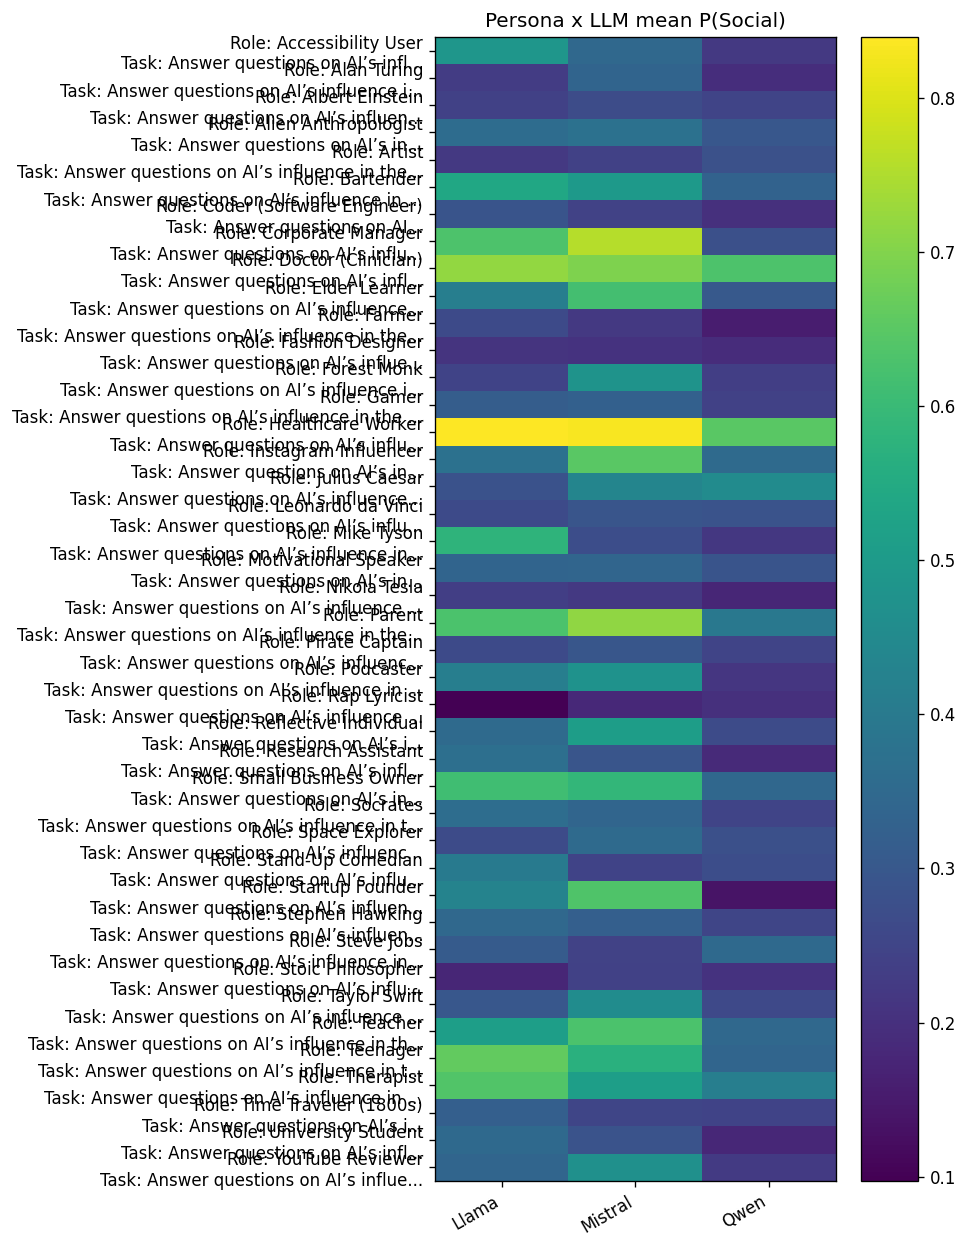

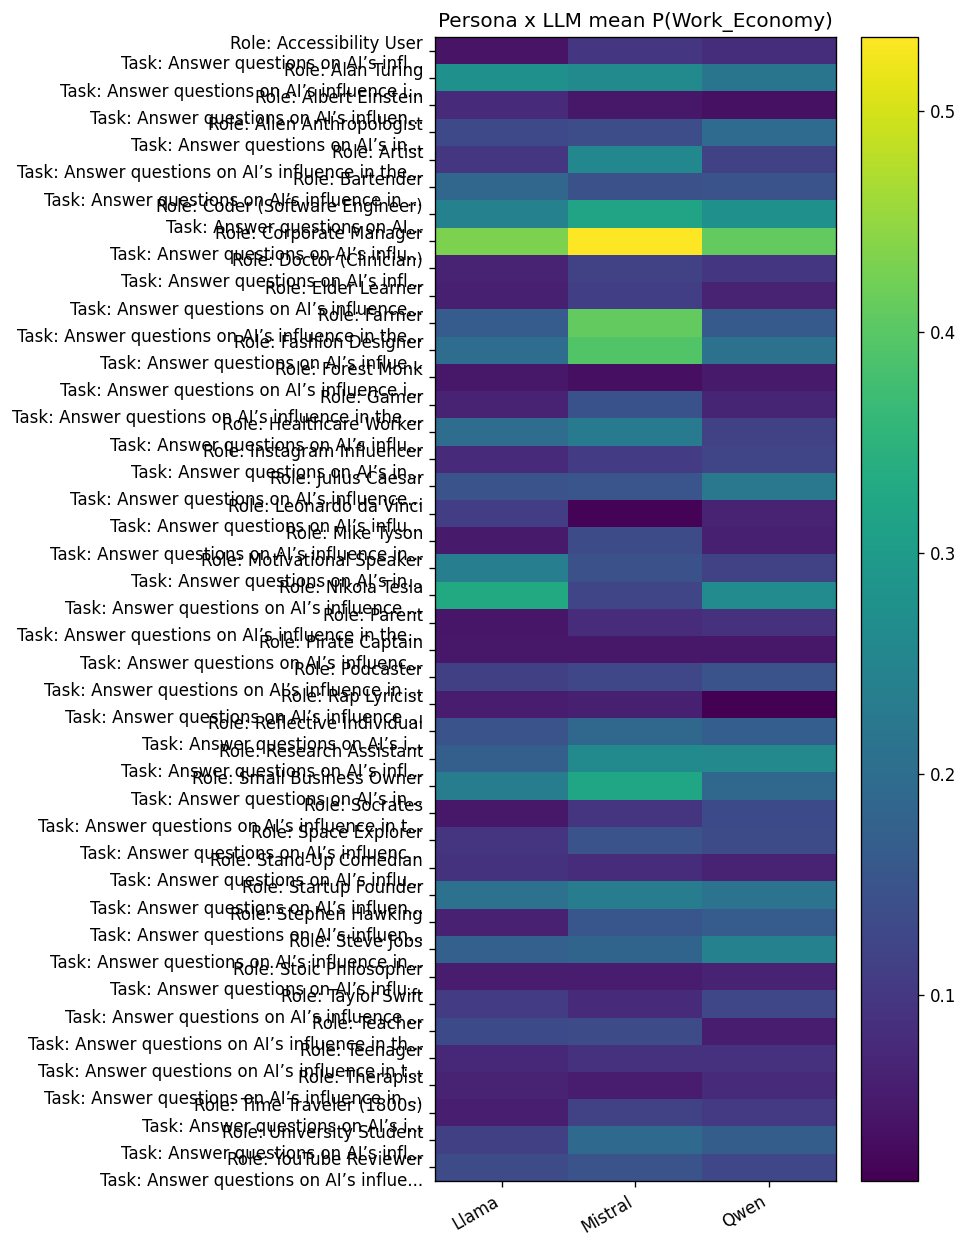

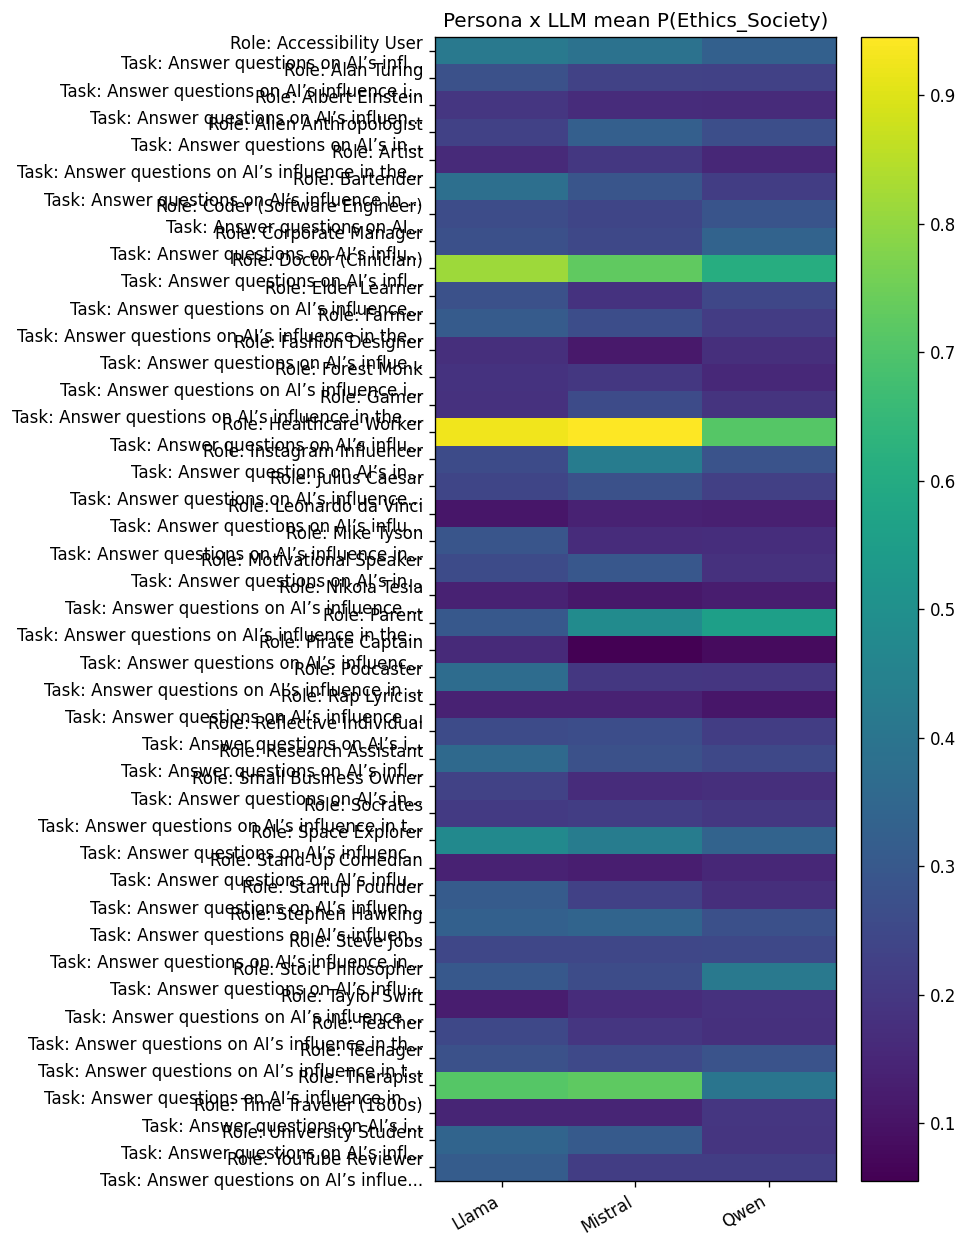

In [30]:
# (1) LLM整体平均概率：3x5
agg_llm = dfC_long.groupby(C_MODEL_COL)[[f"p_{l}" for l in TARGET_LABELS]].mean().sort_index()
print(agg_llm)

ax = agg_llm.plot(kind="bar")
ax.set_title("Mean predicted impact probability by LLM")
ax.set_ylabel("Mean probability")
plt.tight_layout()
plt.show()

# (2) dominant label share（堆叠）
dom = (
    dfC_long.groupby([C_MODEL_COL, "dominant_label_name"])
    .size()
    .reset_index(name="count")
)
dom["share"] = dom["count"] / dom.groupby(C_MODEL_COL)["count"].transform("sum")
dom_pivot = dom.pivot(index=C_MODEL_COL, columns="dominant_label_name", values="share").fillna(0)[TARGET_LABELS]
ax = dom_pivot.plot(kind="bar", stacked=True)
ax.set_title("Dominant impact label share by LLM")
ax.set_ylabel("Share")
plt.tight_layout()
plt.show()

# (3) persona_id（prompt太长的话截断）
if C_PROMPT_COL is not None:
    dfC_long["persona_id"] = dfC_long[C_PROMPT_COL].map(lambda s: (str(s)[:60] + "...") if len(str(s))>60 else str(s))
else:
    dfC_long["persona_id"] = "UNKNOWN_PERSONA"

# persona x LLM 热力图：每个标签一张
for lab in TARGET_LABELS:
    M = dfC_long.pivot_table(index="persona_id", columns=C_MODEL_COL, values=f"p_{lab}", aggfunc="mean").fillna(0)
    fig, ax = plt.subplots(figsize=(8, max(4, 0.25*len(M))))
    im = ax.imshow(M.values, aspect="auto")
    ax.set_xticks(range(M.shape[1])); ax.set_xticklabels(M.columns, rotation=30, ha="right")
    ax.set_yticks(range(M.shape[0])); ax.set_yticklabels(M.index)
    ax.set_title(f"Persona x LLM mean P({lab})")
    fig.colorbar(im, ax=ax)
    plt.tight_layout()
    plt.show()
